# Plot of precipitation data availability over the entire time series

In [1]:
import os
os.chdir('/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/')

# general
import glob
import datetime as dt
from pathlib import Path

# data 
import xarray as xr 
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px 
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio

# Configure Plotly for Jupyter notebooks
pio.renderers.default = "notebook"
# Alternative renderers you can try if "notebook" doesn't work:
# pio.renderers.default = "plotly_mimetype+notebook"
# pio.renderers.default = "jupyter_lab"

# helper tools
from metpy import calc, units
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from utils.helper_funcs import TaylorDiagram

In [2]:
DATA_DIR = Path("/storage/dlhogan/precipitation-rodeo/data/processed/final/")
OUTPUT_DIR = Path("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/figures/")
TABLE_OUTPUT_DIR = Path("/home/dlhogan/projects/phd-repos/S3-precipitation-rodeo/04_products/tables/")
GRIDDED_VARS = ['ERA5-Land','PRISM','billy_barr_precip']

In [3]:
def get_dataset(site, directory):
    """Load dataset for a given site."""
    # precipitation datasets
    gothic_prcp_ds = xr.open_dataset(directory / f'{site}_precipitation_30min.nc')
    era5_land_prcp_ds = xr.open_dataset(directory / f'ERA5-Land/era5_land_gothic_1hr.nc')
    prism_prcp_ds = xr.open_dataset(directory / f'PRISM/prism_site_data.nc').sel(site=site)
    ds = xr.merge([gothic_prcp_ds, era5_land_prcp_ds, prism_prcp_ds], compat='override')
    # rename tp to ERA5-Land and ppt to PRISM for clarity
    ds = ds.rename({'tp':'ERA5-Land', 'ppt':'PRISM'})
    # drop crs datavar if it exists
    if 'crs' in ds.data_vars:
        ds = ds.drop_vars('crs')
    return ds

In [4]:
gothic_ds = get_dataset("gothic", DATA_DIR)
kettle_ponds_ds = get_dataset("kettle_ponds", DATA_DIR)

In [69]:
# drop unwanted coordinates
vars_to_drop = ['latitude', 'longitude', 'site', 'spatial_ref', 'lat', 'lon', 'x', 'y', 'sail_pwd_rain', 'sail_squire_rain', 'rain_rate_A','precip_type']
for var in vars_to_drop:
    if var in gothic_ds.coords or var in gothic_ds.data_vars:
        gothic_ds = gothic_ds.drop_vars(var)
    if var in kettle_ponds_ds.coords or var in kettle_ponds_ds.data_vars:
        kettle_ponds_ds = kettle_ponds_ds.drop_vars(var)

In [70]:
time_slice = slice('2021-10-01', '2023-06-12')
kettle_ponds_df = kettle_ponds_ds.sel(time=time_slice).to_dataframe()
gothic_df = gothic_ds.sel(time=time_slice).to_dataframe()

In [71]:
kp_qc_cols = [col for col in kettle_ponds_df.columns if 'qc' in col]
kettle_ponds_qc_df = kettle_ponds_df[kp_qc_cols]
kettle_ponds_noqc_df = kettle_ponds_df.drop(columns=kp_qc_cols)

gothic_qc_cols = [col for col in gothic_df.columns if 'qc' in col]
gothic_qc_df = gothic_df[gothic_qc_cols]
gothic_noqc_df = gothic_df.drop(columns=gothic_qc_cols)

In [ ]:
sos_ds = xr.open_dataset("/storage/dlhogan/precipitation-rodeo/data/processed/SOS/sos_ds_30min.nc")


In [152]:
snow_pillow_data_availability = pd.DataFrame(index=pd.date_range(start='2021-10-01', end='2023-06-30', freq='ME'))
for snow_pillow in ['SWE_p1_c', 'SWE_p2_c', 'SWE_p3_c', 'SWE_p4_c']:
    snow_pillow_data_availability[snow_pillow] = (((sos_ds.diff('time') < 10) & (sos_ds.time < pd.Timestamp('2023-05-15'))).resample(time='ME').sum()/((sos_ds.diff('time') < 10) & 
                                                                                                      (sos_ds.time < pd.Timestamp('2023-05-15'))).resample(time='ME').count()).to_pandas()

In [153]:
kettle_ponds_quality_df = kettle_ponds_noqc_df.copy()
for col in kettle_ponds_noqc_df.columns:
    if 'ld' in col and 'uncorrected' not in col:
        continue
    elif 'squire' in col and 'm2009_1' not in col:
        continue
    elif col == 'precip_type':
        continue
    elif 'SWE' in col:
        # drop sos from the col name
        col_name = col.replace('sos_', '')
        kettle_ponds_quality_df[col] = kettle_ponds_qc_df[f'qc_{col_name}_missing'] + kettle_ponds_qc_df[f'qc_{col_name}_bad']
    elif col in['ERA5-Land','PRISM']:
        continue
    else:
        kettle_ponds_quality_df[col] = kettle_ponds_qc_df[f'qc_bad_{col}'] + kettle_ponds_qc_df[f'qc_missing_{col}']


In [154]:
gothic_quality_df = gothic_noqc_df.copy()
for col in gothic_noqc_df.columns:
    if 'ld' in col and 'uncorrected' not in col:
        continue
    elif 'squire' in col and 'm2009_1' not in col:
        continue
    elif col == 'precip_type':
        continue
    elif 'SWE' in col:
        # drop sos from the col name
        col_name = col.replace('sos_', '')
        gothic_quality_df[col] = gothic_qc_df[f'qc_{col_name}_missing'] + gothic_qc_df[f'qc_{col_name}_bad']
    elif col in['ERA5-Land','PRISM']:
        continue
    else:
        gothic_quality_df[col] = gothic_qc_df[f'qc_bad_{col}'] + gothic_qc_df[f'qc_missing_{col}']

In [155]:
# if value is > 0, set to True
gothic_quality_df = gothic_quality_df > 0
kettle_ponds_quality_df = kettle_ponds_quality_df > 0

In [156]:

# get monthly non-nan counts for each instrument/product
kettle_ponds_counts = 1 - (kettle_ponds_quality_df.resample('ME').sum().transpose() / kettle_ponds_df.resample('ME').size())
gothic_counts = 1 - (gothic_quality_df.resample('ME').sum().transpose() / gothic_df.resample('ME').size())

# fill PRISM and ERA5-Land with 1
kettle_ponds_counts.loc['PRISM'] = 1.0
kettle_ponds_counts.loc['ERA5-Land'] = 1.0
gothic_counts.loc['PRISM'] = 1.0
gothic_counts.loc['ERA5-Land'] = 1.0

# set squire values to nan for all months except Dec - Mar
for month in range(1,13):
    if month not in [12,1,2,3]:
        kettle_ponds_counts.loc['sail_squire_m2009_1', kettle_ponds_counts.columns.month == month] = np.nan
        gothic_counts.loc['sail_squire_m2009_1', gothic_counts.columns.month == month] = np.nan
# drop all other squires and rename the m2009_1 column to SQUIRE
kettle_ponds_counts = kettle_ponds_counts.drop(index=[col for col in kettle_ponds_counts.index if 'squire' in col and 'm2009_1' not in col])
kettle_ponds_counts = kettle_ponds_counts.rename(index={'sail_squire_m2009_1':'SQUIRE'})
gothic_counts = gothic_counts.drop(index=[col for col in gothic_counts.index if 'squire' in col and 'm2009_1' not in col])
gothic_counts = gothic_counts.rename(index={'sail_squire_m2009_1':'SQUIRE'})

# for the SOS SWE products, set values to nan for all months between October and June in 2022-2023
kettle_ponds_counts.loc['sos_SWE_p1', (kettle_ponds_counts.columns.year.isin([2021,2022]))] = np.nan
kettle_ponds_counts.loc['sos_SWE_p2', (kettle_ponds_counts.columns.year.isin([2021,2022]))] = np.nan
kettle_ponds_counts.loc['sos_SWE_p3', (kettle_ponds_counts.columns.year.isin([2021,2022]))] = np.nan
kettle_ponds_counts.loc['sos_SWE_p4', (kettle_ponds_counts.columns.year.isin([2021,2022]))] = np.nan

# add snow pillow data availability
for snow_pillow in ['SWE_p1_c', 'SWE_p2_c', 'SWE_p3_c', 'SWE_p4_c']:
    kettle_ponds_counts.loc[f'sos_{snow_pillow.replace("_c", "")}'] = snow_pillow_data_availability[snow_pillow].T.values



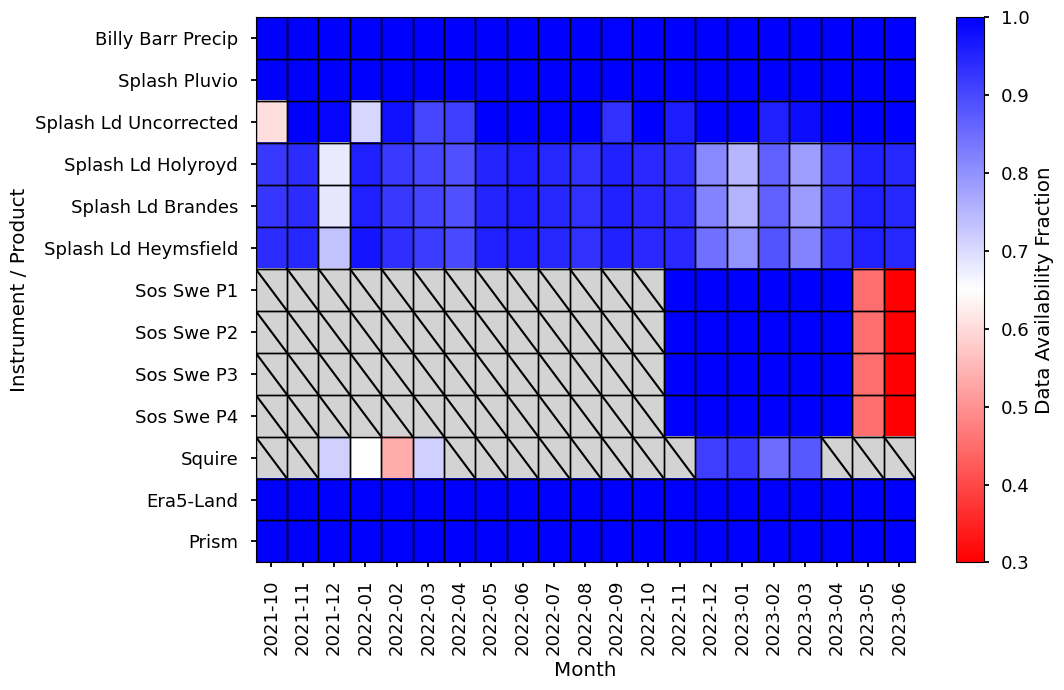

In [160]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

Z = kettle_ponds_counts.values
Z_masked = np.ma.masked_invalid(Z)

x_labels = kettle_ponds_counts.columns.strftime("%Y-%m")
y_labels = kettle_ponds_counts.index.str.replace("_", " ").str.title()

# Colormap that grays out NaN
cmap = matplotlib.colormaps.get_cmap("bwr_r").copy()
cmap.set_bad(color="lightgray")

fig, ax = plt.subplots(figsize=(11, 7))
plt.style.use('seaborn-v0_8-talk')
# Heatmap
cax = ax.imshow(
    Z_masked,
    cmap=cmap,
    vmin=0.3,
    vmax=1.0,
    aspect="auto",
    origin="upper",
)

# Colorbar
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label("Data Availability Fraction")

# Axis labels
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=90)

ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels)

ax.set_xlabel("Month")
ax.set_ylabel("Instrument / Product")
# ax.set_title("Data Availability Heatmaps")

rows, cols = Z.shape

# Outline + diagonal slash for NaNs
for r in range(rows):
    for c in range(cols):

        # Draw black outline
        rect = plt.Rectangle(
            (c - 0.5, r - 0.5), 1, 1,
            fill=False, edgecolor="black", linewidth=1
        )
        ax.add_patch(rect)

        # If NaN, draw diagonal slash
        if np.isnan(Z[r, c]):
            ax.plot(
                [c - 0.5, c + 0.5],
                [r - 0.5, r + 0.5],
                color="black",
                linewidth=1.5
            )

plt.tight_layout()

# plt.savefig(OUTPUT_DIR / 'data_availability_heatmap_kettle_ponds.png', dpi=300)


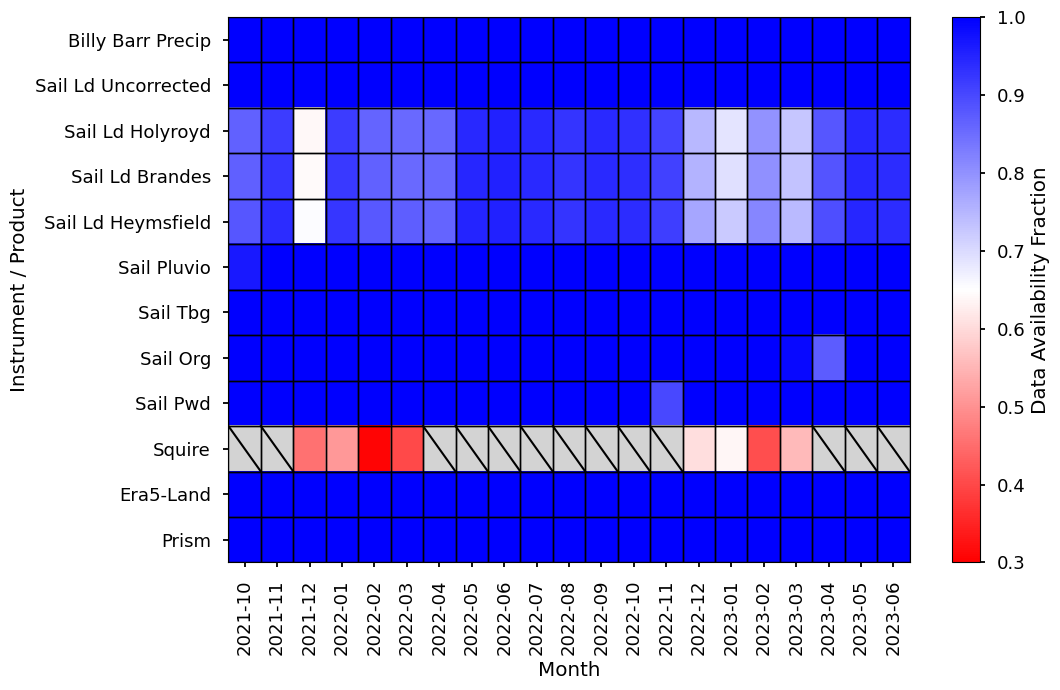

In [159]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

Z = gothic_counts.values
Z_masked = np.ma.masked_invalid(Z)

x_labels = gothic_counts.columns.strftime("%Y-%m")
y_labels = gothic_counts.index.str.replace("_", " ").str.title()

# Colormap that grays out NaN
cmap = matplotlib.colormaps.get_cmap("bwr_r").copy()
cmap.set_bad(color="lightgray")

fig, ax = plt.subplots(figsize=(11, 7))
plt.style.use('seaborn-v0_8-talk')
# Heatmap
cax = ax.imshow(
    Z_masked,
    cmap=cmap,
    vmin=0.3,
    vmax=1.0,
    aspect="auto",
    origin="upper",
)

# Colorbar
cbar = fig.colorbar(cax, ax=ax)
cbar.set_label("Data Availability Fraction")

# Axis labels
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels, rotation=90)

ax.set_yticks(np.arange(len(y_labels)))
ax.set_yticklabels(y_labels)

ax.set_xlabel("Month")
ax.set_ylabel("Instrument / Product")
# ax.set_title("Data Availability Heatmaps")

rows, cols = Z.shape

# Outline + diagonal slash for NaNs
for r in range(rows):
    for c in range(cols):

        # Draw black outline
        rect = plt.Rectangle(
            (c - 0.5, r - 0.5), 1, 1,
            fill=False, edgecolor="black", linewidth=1
        )
        ax.add_patch(rect)

        # If NaN, draw diagonal slash
        if np.isnan(Z[r, c]):
            ax.plot(
                [c - 0.5, c + 0.5],
                [r - 0.5, r + 0.5],
                color="black",
                linewidth=1.5
            )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_availability_heatmap_gothic.png', dpi=300)
